In [67]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
import nltk
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import gensim
import re
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from nltk import ngrams




data_folder = Path("./texts/Lovecraft/")

files = list(data_folder.glob("*.txt"))

files

[PosixPath('texts/Lovecraft/color_out_of_space.txt'),
 PosixPath('texts/Lovecraft/dunwich_horror.txt'),
 PosixPath('texts/Lovecraft/Call_of_cthulhu.txt'),
 PosixPath('texts/Lovecraft/shunned_house.txt')]

In [68]:
stories = {}

for file in files:
    with open(file, encoding="utf-8") as f:
        stories[file.stem] = f.read()

stories.keys()

dict_keys(['color_out_of_space', 'dunwich_horror', 'Call_of_cthulhu', 'shunned_house'])

In [69]:
print(stories["Call_of_cthulhu"][:1000])

_1. The Horror in Clay._

The most merciful thing in the world, I think, is the inability of the
human mind to correlate all its contents. We live on a placid island
of ignorance in the midst of black seas of infinity, and it was not
meant that we should voyage far. The sciences, each straining in its
own direction, have hitherto harmed us little; but some day the piecing
together of dissociated knowledge will open up such terrifying vistas
of reality, and of our frightful position therein, that we shall either
go mad from the revelation or flee from the deadly light into the peace
and safety of a new dark age.

Theosophists have guessed at the awesome grandeur of the cosmic cycle
wherein our world and human race form transient incidents. They have
hinted at strange survivals in terms which would freeze the blood if
not masked by a bland optimism. But it is not from them that there
came the single glimpse of forbidden eons which chills me when I think
of it and maddens me when I dream 

In [70]:
stats = []

for title, text in stories.items():
    
    words = text.split()
    
    stats.append({
        "story": title,
        "word_count": len(words),
        "character_count": len(text)
    })

df = pd.DataFrame(stats)

df

,story,word_count,character_count
0,color_out_of_space,12364,69158
1,dunwich_horror,17183,100253
2,Call_of_cthulhu,11835,70258
3,shunned_house,10717,62939


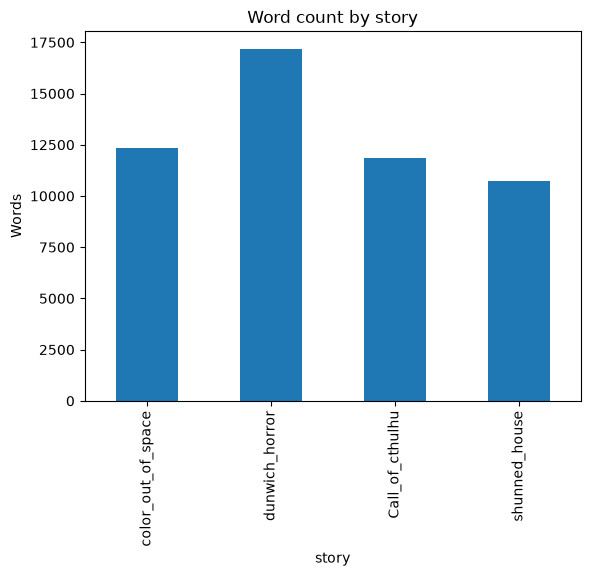

In [71]:
df.plot(
    x="story",
    y="word_count",
    kind="bar",
    legend=False
)

plt.title("Word count by story")
plt.ylabel("Words")
plt.show()

In [72]:
for title, text in stories.items():

    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

    print(
        title,
        "Words:", len(words),
        "Unique:", len(set(words))
    )

color_out_of_space Words: 12462 Unique: 2658
dunwich_horror Words: 17568 Unique: 3873
Call_of_cthulhu Words: 11881 Unique: 3068
shunned_house Words: 10829 Unique: 2913


In [73]:
cthulhu = stories["Call_of_cthulhu"]
color_out = stories["color_out_of_space"]
words = re.findall(r"\b[a-zA-Z]+\b", cthulhu.lower())
c_words = re.findall(r"\b[a-zA-Z]+\b", color_out.lower())







Counter(words).most_common(20)
Counter(words).most_common(20)


[('the', 804),
 ('of', 527),
 ('and', 483),
 ('a', 243),
 ('in', 219),
 ('to', 204),
 ('was', 170),
 ('had', 159),
 ('that', 119),
 ('i', 113),
 ('it', 110),
 ('he', 106),
 ('his', 96),
 ('which', 94),
 ('with', 86),
 ('from', 83),
 ('on', 79),
 ('for', 79),
 ('at', 74),
 ('as', 73)]

In [74]:
stop_words = set(stopwords.words("english"))
filtered_words = [
    word
    for word in words
    if word not in stop_words
]

Counter(filtered_words).most_common(30)

c_filtered_words = [
    c_word
    for c_word in c_words
    if c_word not in stop_words
]

Counter(c_filtered_words).most_common(30)

[('ammi', 78),
 ('nahum', 67),
 ('could', 53),
 ('well', 46),
 ('one', 42),
 ('would', 35),
 ('something', 30),
 ('like', 27),
 ('must', 27),
 ('even', 27),
 ('seemed', 27),
 ('away', 26),
 ('come', 25),
 ('night', 24),
 ('strange', 24),
 ('saw', 24),
 ('nothing', 24),
 ('colour', 24),
 ('place', 23),
 ('seen', 21),
 ('arkham', 20),
 ('old', 20),
 ('house', 20),
 ('things', 20),
 ('men', 20),
 ('ever', 19),
 ('never', 18),
 ('thought', 18),
 ('grey', 18),
 ('gone', 17)]

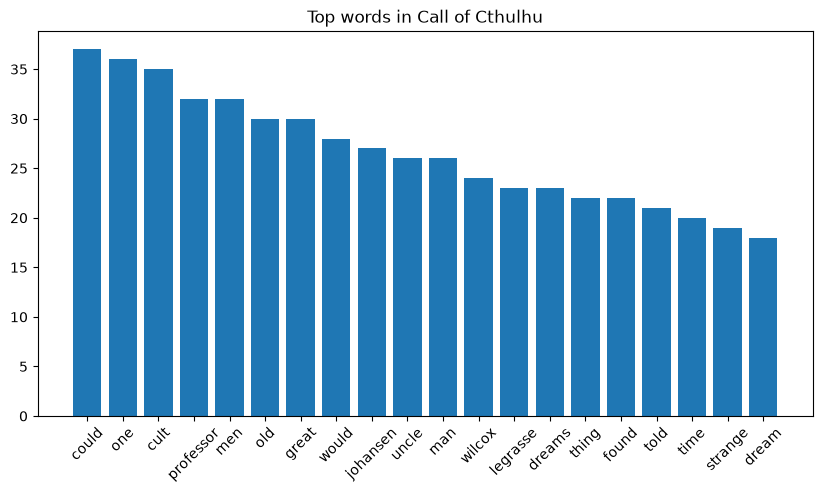

In [75]:
top_words = Counter(filtered_words).most_common(20)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.title("Top words in Call of Cthulhu")
plt.show()

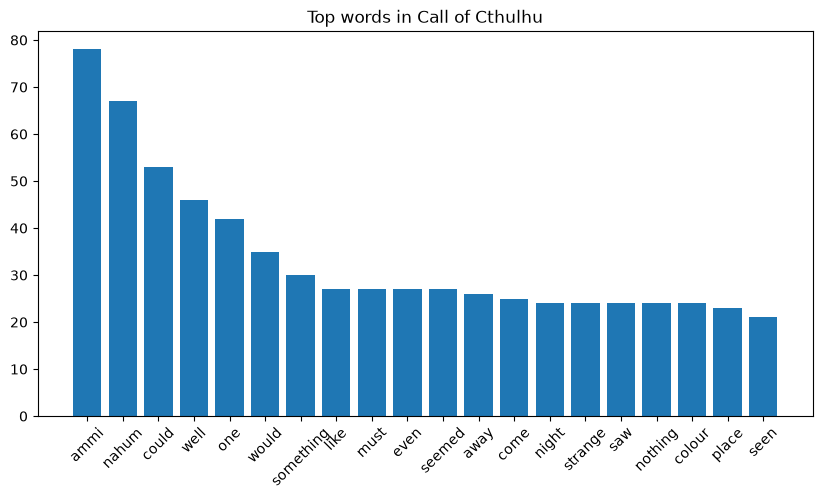

In [76]:
c_top_words = Counter(c_filtered_words).most_common(20)

c_words = [w for w, c in c_top_words]
c_counts = [c for w, c in c_top_words]

plt.figure(figsize=(10,5))
plt.bar(c_words, c_counts)

plt.xticks(rotation=45)
plt.title("Top words in Call of Cthulhu")
plt.show()

In [77]:
unique_words = len(set(filtered_words))
total_words = len(filtered_words)

richness = unique_words / total_words

print(title)
print(f"Total words: {total_words}")
print(f"Unique words: {unique_words}")
print(f"Richness: {richness:.3f}")

longest = sorted(set(filtered_words), key=len, reverse=True)

longest[:20]

shunned_house
Total words: 6225
Unique words: 2949
Richness: 0.474


['bloodthirstiness',
 'impressionistic',
 'anthropological',
 'unconsciousness',
 'unpronounceable',
 'characteristic',
 'impressiveness',
 'correspondence',
 'anthropologist',
 'contradictions',
 'hypersensitive',
 'representation',
 'undecipherable',
 'disappointment',
 'diminutiveness',
 'considerations',
 'indescribable',
 'investigation',
 'hieroglyphics',
 'exceptionally']

In [78]:
documents = list(stories.values())
titles = list(stories.keys())

In [79]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
    max_df=0.8
)

In [80]:
tfidf_matrix = vectorizer.fit_transform(documents)

In [81]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])


['aaaa' 'abandoned' 'abandonment' 'abaout' 'abdomen' 'abdul' 'aberrant'
 'abhorred' 'abhorrent' 'abigail' 'abijah' 'able' 'abnormality'
 'abnormally' 'aboard' 'abode' 'abominable' 'abroad' 'abruptly' 'absence']


In [82]:
print(type(documents))
print(type(documents[0]))
print(documents[0][:200])


<class 'list'>
<class 'str'>
West of Arkham the hills rise wild, and there are valleys with deep
woods that no axe has ever cut. There are dark narrow glens where the
trees slope fantastically, and where thin brooklets trickle wi


In [83]:
print(type(feature_names))
print(feature_names[:20])

<class 'numpy.ndarray'>
['aaaa' 'abandoned' 'abandonment' 'abaout' 'abdomen' 'abdul' 'aberrant'
 'abhorred' 'abhorrent' 'abigail' 'abijah' 'able' 'abnormality'
 'abnormally' 'aboard' 'abode' 'abominable' 'abroad' 'abruptly' 'absence']


In [84]:
tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])

['aaaa' 'abandoned' 'abandonment' 'abaout' 'abdomen' 'abdul' 'aberrant'
 'abhorred' 'abhorrent' 'abigail' 'abijah' 'able' 'abnormality'
 'abnormally' 'aboard' 'abode' 'abominable' 'abroad' 'abruptly' 'absence']


In [85]:
print(len(feature_names))

6996


In [86]:
scores = tfidf_matrix[0].toarray().flatten()

df_tfidf = pd.DataFrame({
    "word": feature_names,
    "score": scores
})

df_tfidf.sort_values(
    "score",
    ascending=False
).head(20)

,word,score
195,ammi,0.585617
3956,nahum,0.503030
1105,colour,0.180190
2682,grey,0.135142
304,arkham,0.118386
2512,gardner,0.105111
4678,professors,0.097603
3773,merwin,0.097603
6993,zenas,0.088790
3781,meteor,0.082587


In [87]:
for i, title in enumerate(titles):

    scores = tfidf_matrix[i].toarray().flatten()

    df = pd.DataFrame({
        "word": feature_names,
        "score": scores
    })

    print(f"\n{title}")
    print(df.sort_values(
        "score",
        ascending=False
    ).head(10))


color_out_of_space
            word     score
195         ammi  0.585617
3956       nahum  0.503030
1105      colour  0.180190
2682        grey  0.135142
304       arkham  0.118386
2512     gardner  0.105111
4678  professors  0.097603
3773      merwin  0.097603
6993       zenas  0.088790
3781      meteor  0.082587

dunwich_horror
               word     score
6811       whateley  0.453083
307        armitage  0.314138
6856         wilbur  0.289973
1844        dunwich  0.223521
2594           glen  0.163110
6831  whippoorwills  0.126863
6812      whateleys  0.102699
255            aout  0.096658
2462           frye  0.096658
573          bishop  0.090617

Call_of_cthulhu
           word     score
1395       cult  0.329371
3309   johansen  0.254086
4677  professor  0.237421
6857     wilcox  0.225854
3471   legrasse  0.216443
6431      uncle  0.192905
1391    cthulhu  0.126130
5317        sea  0.122338
481         bas  0.112927
4166       ones  0.111291

shunned_house
         word     s

In [88]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(tfidf_matrix)

pd.DataFrame(
    similarity,
    index=titles,
    columns=titles
)


,color_out_of_space,dunwich_horror,Call_of_cthulhu,shunned_house
color_out_of_space,1.000000,0.081947,0.049627,0.061344
dunwich_horror,0.081947,1.000000,0.088374,0.084863
Call_of_cthulhu,0.049627,0.088374,1.000000,0.164839
shunned_house,0.061344,0.084863,0.164839,1.000000


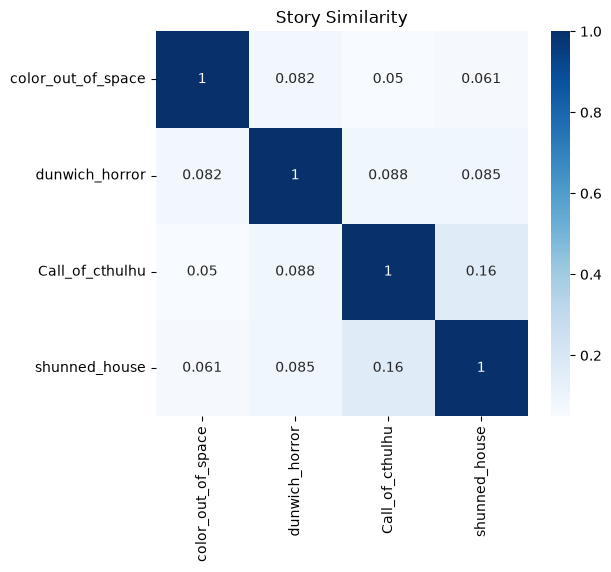

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    similarity,
    annot=True,
    cmap="Blues",
    xticklabels=titles,
    yticklabels=titles
)

plt.title("Story Similarity")
plt.show()


In [90]:
def plot_zipf_and_heaps(words):
    # 1. Zipf's Law Data
    counts = Counter(words)
    frequencies = sorted(counts.values(), reverse=True)
    ranks = np.arange(1, len(frequencies) + 1)
    
    # 2. Heaps' Law Data
    vocab_progress = []
    distinct_words = set()
    # We sample every 100 words to speed up the plot
    for i, word in enumerate(words):
        distinct_words.add(word)
        if i % 100 == 0:
            vocab_progress.append((i, len(distinct_words)))
    
    tokens_n, vocab_v = zip(*vocab_progress)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Zipf Plot (Log-Log)
    ax1.loglog(ranks, frequencies, marker=".", linestyle='none', alpha=0.5)
    ax1.set_title("Zipf's Law (Log-Log Scale)")
    ax1.set_xlabel("Rank of word")
    ax1.set_ylabel("Frequency")
    ax1.grid(True, which="both", ls="-", alpha=0.2)

    # Heaps Plot
    ax2.plot(tokens_n, vocab_v, color='red')
    ax2.set_title("Heaps' Law (Vocabulary Growth)")
    ax2.set_xlabel("Number of Tokens")
    ax2.set_ylabel("Number of Distinct Words")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

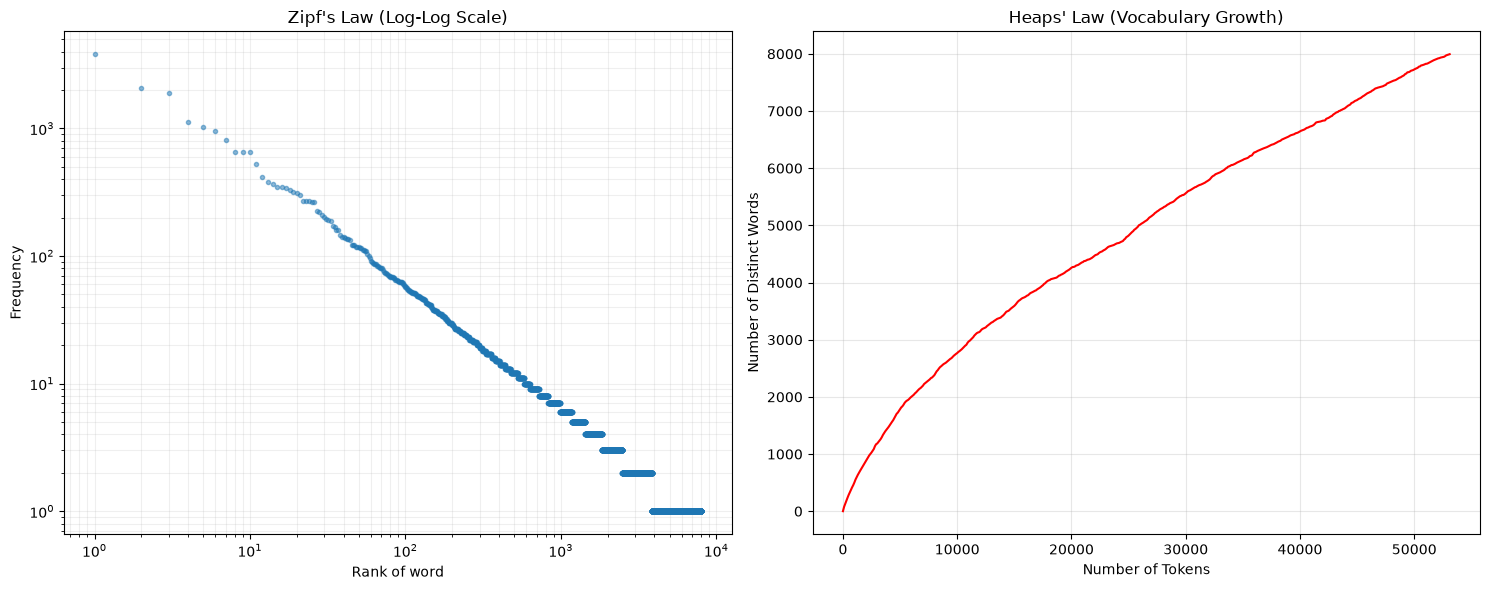

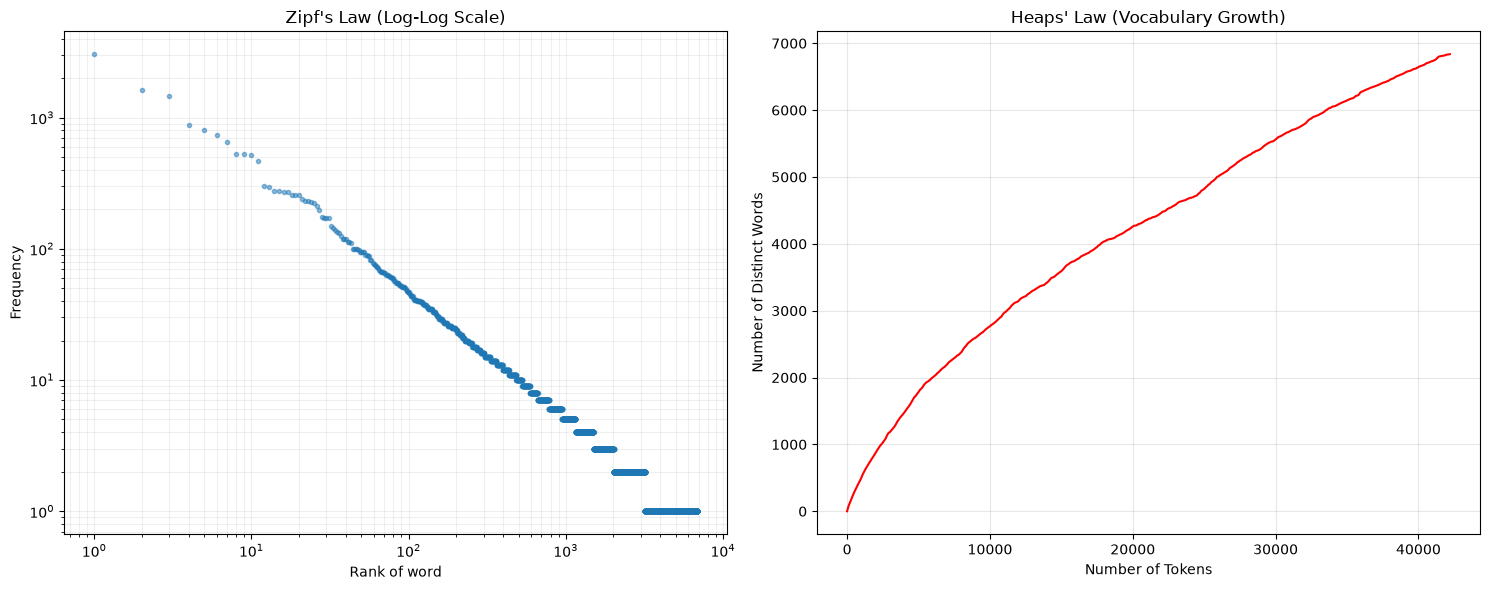

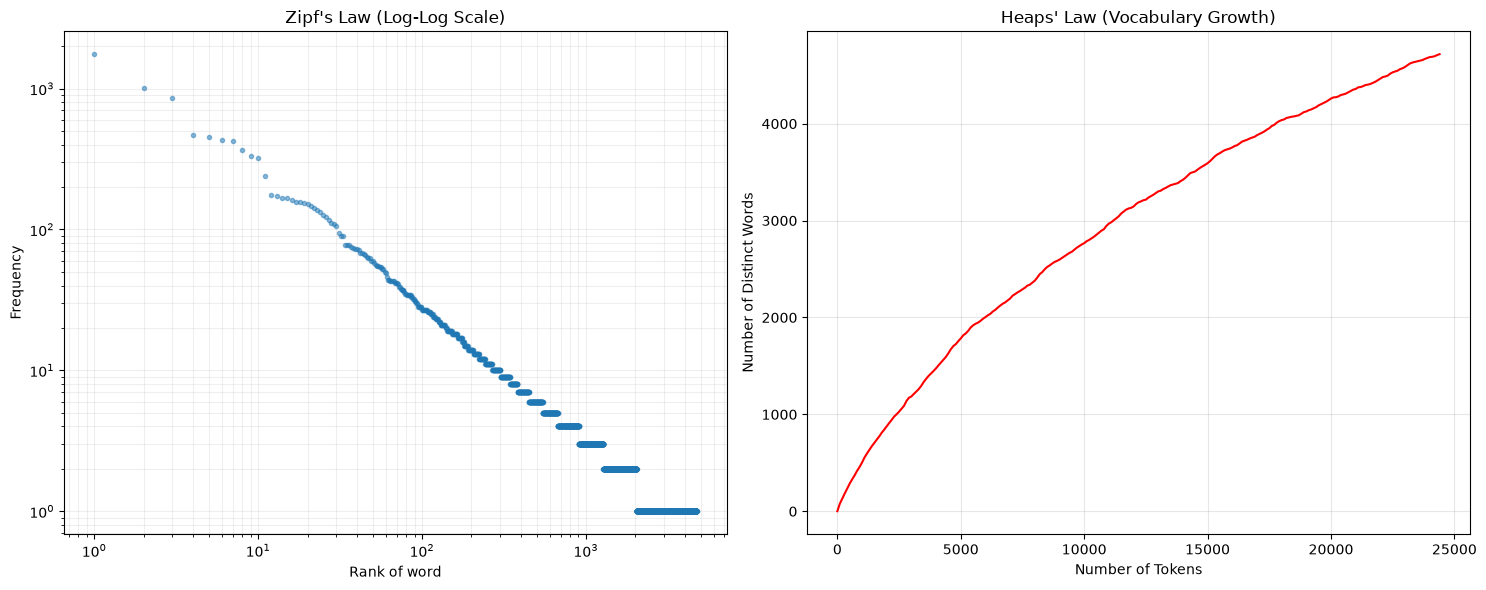

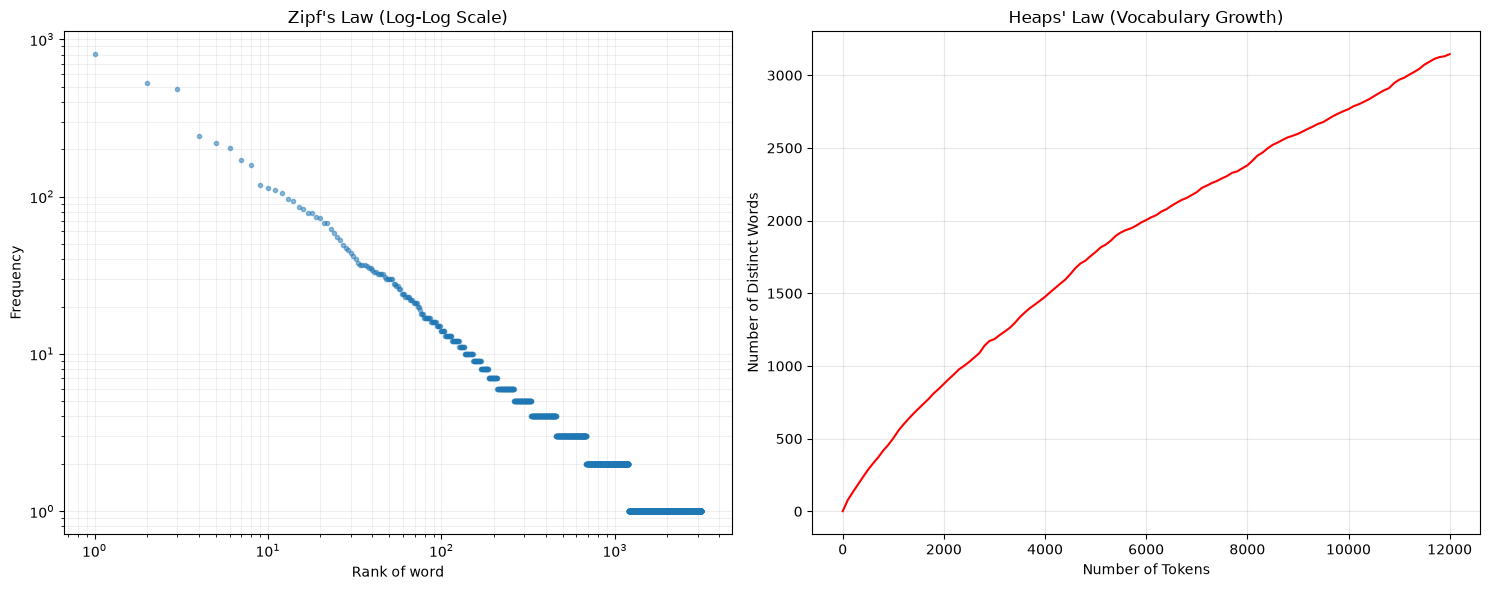

In [91]:
corpus_1 = " ".join([stories["Call_of_cthulhu"], stories["color_out_of_space"], stories["dunwich_horror"], stories["shunned_house"]])
zipfwords_1 = re.findall(r'\w+', corpus_1.lower())
plot_zipf_and_heaps(zipfwords_1)

corpus_2 = " ".join([stories["Call_of_cthulhu"], stories["color_out_of_space"], stories["dunwich_horror"]])
zipfwords_2 = re.findall(r'\w+', corpus_2.lower())
plot_zipf_and_heaps(zipfwords_2)

corpus_3 = " ".join([stories["Call_of_cthulhu"], stories["color_out_of_space"]])
zipfwords_3 = re.findall(r'\w+', corpus_3.lower())
plot_zipf_and_heaps(zipfwords_3)

corpus_4 = " ".join([stories["Call_of_cthulhu"]])
zipfwords_4 = re.findall(r'\w+', corpus_4.lower())
plot_zipf_and_heaps(zipfwords_4)

In [92]:
counts_4 = Counter(zipfwords_4)

hapax_4 = sum(1 for c in counts_4.values() if c == 1)

print(f"Unique words appearing only once: {hapax_4}")
print(f"Percentage: {100*hapax_4/len(counts_4):.1f}%")

Unique words appearing only once: 1954
Percentage: 62.0%


In [93]:
counts_3 = Counter(zipfwords_3)

hapax_3 = sum(1 for c in counts_3.values() if c == 1)

print(f"Unique words appearing only once: {hapax_3}")
print(f"Percentage: {100*hapax_3/len(counts_3):.1f}%")

Unique words appearing only once: 2691
Percentage: 57.0%


In [94]:
counts_2 = Counter(zipfwords_2)

hapax_2 = sum(1 for c in counts_2.values() if c == 1)

print(f"Unique words appearing only once: {hapax_2}")
print(f"Percentage: {100*hapax_2/len(counts_2):.1f}%")

Unique words appearing only once: 3647
Percentage: 53.3%


In [95]:
counts_1 = Counter(zipfwords_1)

hapax_1 = sum(1 for c in counts_1.values() if c == 1)

print(f"Unique words appearing only once: {hapax_1}")
print(f"Percentage: {100*hapax_1/len(counts_1):.1f}%")

Unique words appearing only once: 4145
Percentage: 51.9%


In [96]:
words_all = []
for title, text in stories.items():
    i = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    words_all.append(i)

clean_words_all = []

for i in words_all:
    n = [n for n in i if n not in stop_words]
    clean_words_all.append(n)




In [97]:
# 1. Generate Bigrams
bigrams = list(ngrams(clean_words_all[0], 2))
bigram_counts = Counter(bigrams)

# 2. Generate Trigrams
trigrams = list(ngrams(clean_words_all[0], 3))
trigram_counts = Counter(trigrams)

print("Top 10 Bigrams:")
for gram, count in bigram_counts.most_common(10):
    print(f"{gram}: {count}")

Top 10 Bigrams:
('blasted', 'heath'): 10
('strange', 'days'): 9
('merwin', 'zenas'): 7
('attic', 'room'): 5
('ammi', 'could'): 5
('sky', 'like'): 4
('next', 'morning'): 4
('gardner', 'place'): 4
('nahum', 'said'): 4
('ten', 'acre'): 4


In [98]:
# 1. Generate Bigrams
bigrams = list(ngrams(clean_words_all[1], 2))
bigram_counts = Counter(bigrams)

# 2. Generate Trigrams
trigrams = list(ngrams(clean_words_all[1], 3))
trigram_counts = Counter(trigrams)

print("Top 10 Bigrams:")
for gram, count in bigram_counts.most_common(10):
    print(f"{gram}: {count}")

Top 10 Bigrams:
('wilbur', 'whateley'): 16
('old', 'whateley'): 16
('dr', 'armitage'): 16
('sentinel', 'hill'): 13
('earl', 'sawyer'): 9
('spring', 'glen'): 9
('hill', 'noises'): 8
('mis', 'corey'): 8
('cold', 'spring'): 7
('seth', 'bishop'): 7


In [99]:
# 1. Generate Bigrams
bigrams = list(ngrams(clean_words_all[2], 2))
bigram_counts = Counter(bigrams)

# 2. Generate Trigrams
trigrams = list(ngrams(clean_words_all[2], 3))
trigram_counts = Counter(trigrams)

print("Top 10 Bigrams:")
for gram, count in bigram_counts.most_common(10):
    print(f"{gram}: {count}")

Top 10 Bigrams:
('professor', 'angell'): 14
('bas', 'relief'): 11
('old', 'ones'): 11
('r', 'lyeh'): 9
('young', 'wilcox'): 8
('inspector', 'legrasse'): 6
('great', 'cthulhu'): 6
('new', 'orleans'): 5
('professor', 'webb'): 5
('great', 'old'): 5


In [100]:
# 1. Generate Bigrams
bigrams = list(ngrams(clean_words_all[3], 2))
bigram_counts = Counter(bigrams)

# 2. Generate Trigrams
trigrams = list(ngrams(clean_words_all[3], 3))
trigram_counts = Counter(trigrams)

print("Top 10 Bigrams:")
for gram, count in bigram_counts.most_common(10):
    print(f"{gram}: {count}")

Top 10 Bigrams:
('shunned', 'house'): 17
('benefit', 'street'): 12
('rhoby', 'harris'): 7
('carrington', 'harris'): 6
('mercy', 'dexter'): 5
('back', 'street'): 4
('elihu', 'whipple'): 4
('william', 'harris'): 4
('ann', 'white'): 4
('house', 'benefit'): 3
